# Consultoría InmoValor: Modelado Predictivo mediante Redes Neuronales Artificiales

## Clasificación de propiedades por categoría de precio

*Empresa analizada:* **SmartStay Advisors**  
*Curso:* CC3074 - Minería de Datos  
*Tema:* Redes Neuronales Artificiales para clasificación

*Integrantes de la investigación:*
- Vianka Castro - 23201
- Ricardo Godinez - 23247
- Felipe Aguilar - 23195

---

### Propósito de esta sección

Esta parte del informe desarrolla los primeros pasos de la entrega de Redes Neuronales Artificiales. El objetivo es construir modelos capaces de clasificar las propiedades de Airbnb según la categoría de precio definida previamente: **Económica**, **Intermedia** o **Cara**.

Para que la comparación sea válida frente a los modelos trabajados en entregas anteriores, se conserva la misma lógica metodológica utilizada en el notebook de SVM: limpieza base del conjunto de datos, creación de la variable `categoria_precio`, separación 70/30, semilla `random_state=42` y partición estratificada por categoría de precio.

## Preparación del entorno de trabajo

En esta sección se cargan las librerías necesarias para el análisis. Se utilizan herramientas de `pandas` y `numpy` para manipulación de datos, y componentes de `scikit-learn` para preparar variables, construir pipelines y entrenar redes neuronales de clasificación.

In [24]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.base import clone

import numpy as np
import pandas as pd
try:
    import pyreadr
except ImportError as exc:
    raise ImportError("No se encontró la librería pyreadr. Instálala con: pip install pyreadr") from exc
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

RANDOM_STATE = 42
TEST_SIZE = 0.30


def columnas_categoricas(dataframe, excluir=None):
    """Devuelve columnas categóricas o textuales, excluyendo las que se indiquen."""
    excluir = set(excluir or [])
    cols = []
    for col in dataframe.columns:
        if col in excluir:
            continue
        dtype = dataframe[col].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(dtype)
        ):
            cols.append(col)
    return cols


def crear_onehot_encoder():
    """Crea un OneHotEncoder compatible con versiones nuevas y anteriores de scikit-learn."""
    try:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse=True)

print('Entorno preparado correctamente.')

Entorno preparado correctamente.


## Carga del conjunto de datos

El conjunto de datos utilizado es `listings.RData`, el mismo archivo empleado en las entregas anteriores. La variable `price` se convierte a formato numérico porque usualmente viene como texto con símbolos de moneda o separadores de miles.

In [25]:
ruta_datos = Path('listings.RData')

if not ruta_datos.exists():
    raise FileNotFoundError(
        "No se encontró el archivo 'listings.RData'. "
        "Coloca este notebook en la misma carpeta del archivo de datos o actualiza la variable ruta_datos."
    )

resultado = pyreadr.read_r(str(ruta_datos))
df = list(resultado.values())[0]

print(f'Dimensiones iniciales del dataset: {df.shape}')
print('Primeras columnas disponibles:')
print(df.columns[:12].tolist())

# Conversión robusta de price a numérico.
precio_limpio = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['price'] = pd.to_numeric(precio_limpio, errors='coerce')

print('Conversión de price completada.')
print(df['price'].describe().round(2))

Dimensiones iniciales del dataset: (171748, 80)
Primeras columnas disponibles:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name']
Conversión de price completada.
count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price, dtype: float64


## Limpieza inicial del conjunto de datos

Antes de construir los modelos, se eliminan registros sin precio, se descartan columnas completamente vacías y se imputan valores faltantes. Este paso permite que el preprocesamiento posterior trabaje con datos consistentes sin perder observaciones innecesariamente.

In [26]:
df = df.replace([np.inf, -np.inf], np.nan)

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

print('=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===')
print(f'Columnas con vacíos: {len(faltantes)}')
print('Top 10 columnas con más vacíos:')
print(faltantes.head(10))

print('\n=== PORCENTAJE DE VACÍOS TOP 10 ===')
porcentajes = (faltantes / len(df)) * 100
print((porcentajes.head(10).round(2)).astype(str) + ' %')

# Se elimina únicamente la fila sin variable objetivo de precio.
df = df.dropna(subset=['price']).copy()
df = df.dropna(axis=1, how='all')

numericas_df = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas_df:
    numericas_df.remove('price')

categoricas_df = columnas_categoricas(df, excluir=['price'])

if numericas_df:
    imputador_num = SimpleImputer(strategy='median')
    df[numericas_df] = imputador_num.fit_transform(df[numericas_df])

if categoricas_df:
    imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')
    df[categoricas_df] = imputador_cat.fit_transform(df[categoricas_df])

print('\nFilas sin precio eliminadas y faltantes imputados.')
print('Total de nulos restantes:', int(df.isnull().sum().sum()))
print('Dimensiones luego de limpieza:', df.shape)

=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===
Columnas con vacíos: 23
Top 10 columnas con más vacíos:
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
dtype: int64

=== PORCENTAJE DE VACÍOS TOP 10 ===
calendar_updated                100.0 %
price                           55.61 %
estimated_revenue_l365d         55.61 %
neighbourhood_group_cleansed    29.51 %
review_scores_value             23.48 %
review_scores_location          23.48 %
review_scores_checkin           23.48 %
review_scores_accuracy          23.47 %
review_scores_communication     23.47 %
review_scores_cleanliness       23.47 %
dtype: str

Filas sin precio eliminadas y faltantes imputa

## Variable respuesta: categoría de precio

Para clasificar las propiedades, el precio se transforma en una variable categórica de tres niveles usando terciles. Esta decisión mantiene clases balanceadas y permite que la red neuronal aprenda a diferenciar propiedades **Económicas**, **Intermedias** y **Caras**.

Las columnas binarias `es_economica`, `es_intermedia` y `es_cara` se conservan como apoyo descriptivo, aunque el modelo multiclase utilizará directamente `categoria_precio`.

In [27]:
q1, q2 = df['price'].astype(float).quantile([1/3, 2/3])

df['categoria_precio'] = pd.cut(
    df['price'].astype(float),
    bins=[-float('inf'), q1, q2, float('inf')],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
)

df['es_economica'] = (df['categoria_precio'] == 'Economica').astype(int)
df['es_intermedia'] = (df['categoria_precio'] == 'Intermedia').astype(int)
df['es_cara'] = (df['categoria_precio'] == 'Cara').astype(int)

print('Puntos de corte usados para categoria_precio:')
print(f'q1 tercil bajo: {q1:.2f}')
print(f'q2 tercil alto: {q2:.2f}')

print('\nDistribución de categoria_precio:')
distribucion_categoria = df['categoria_precio'].value_counts().sort_index()
print(distribucion_categoria)
print('\nProporción por categoría:')
print((distribucion_categoria / len(df)).round(4))

print('\nEjemplo de codificación:')
display(df[['price', 'categoria_precio', 'es_economica', 'es_intermedia', 'es_cara']].head())

Puntos de corte usados para categoria_precio:
q1 tercil bajo: 143.00
q2 tercil alto: 268.00

Distribución de categoria_precio:
categoria_precio
Economica     25689
Intermedia    25153
Cara          25404
Name: count, dtype: int64

Proporción por categoría:
categoria_precio
Economica     0.3369
Intermedia    0.3299
Cara          0.3332
Name: count, dtype: float64

Ejemplo de codificación:


,price,categoria_precio,es_economica,es_intermedia,es_cara
0,97.0,Economica,1,0,0
1,160.0,Intermedia,0,1,0
2,38.0,Economica,1,0,0
3,145.0,Intermedia,0,1,0
4,58.0,Economica,1,0,0


## Conformación de variables predictoras

Se retiran columnas que no deben usarse como predictores directos del modelo, especialmente identificadores, fechas de extracción, coordenadas y la propia variable objetivo. También se limita el uso de variables categóricas a aquellas con una cardinalidad manejable para evitar una matriz excesivamente grande después del `OneHotEncoder`.

In [28]:
filas_sanas = df['categoria_precio'].notna()
df_limpio = df[filas_sanas].copy()

columnas_a_botar = [
    'price', 'categoria_precio', 'es_economica', 'es_intermedia', 'es_cara',
    'id', 'scrape_id', 'host_id', 'last_scraped', 'calendar_last_scraped',
    'first_review', 'last_review',
    'latitude', 'longitude',
    'neighbourhood_group_cleansed',
    'host_verifications'
]

X = df_limpio.drop(columns=[col for col in columnas_a_botar if col in df_limpio.columns])
X = X.replace([np.inf, -np.inf], np.nan)

# Se eliminan columnas auxiliares binarias mal codificadas que pueden duplicar información.
columnas_falsas = [col for col in X.columns if col.endswith('_f') and X[col].nunique(dropna=True) <= 2]
X = X.drop(columns=columnas_falsas, errors='ignore')

# Algunas variables pueden venir como texto aunque conceptualmente sean numéricas.
columnas_forzar_numero = ['accommodates', 'bathrooms', 'bedrooms', 'beds']
for col in columnas_forzar_numero:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]

if categoricas:
    X[categoricas] = X[categoricas].astype(str)

Y_strata = df_limpio['categoria_precio']
Y_dicotomicas = df_limpio[['es_economica', 'es_intermedia', 'es_cara']]

print('Variables predictoras preparadas:')
print(f'- Total de columnas X: {X.shape[1]}')
print(f'- Variables numéricas usadas: {len(numericas)}')
print(f'- Variables categóricas usadas para OneHotEncoder: {len(categoricas)}')
print(f'- Columnas categóricas excluidas por alta cardinalidad: {len(categoricas_crudas) - len(categoricas)}')

Variables predictoras preparadas:
- Total de columnas X: 67
- Variables numéricas usadas: 30
- Variables categóricas usadas para OneHotEncoder: 10
- Columnas categóricas excluidas por alta cardinalidad: 27


## Mismos conjuntos de entrenamiento y prueba

Para conservar comparabilidad con los modelos anteriores, se usa una partición de **70% entrenamiento** y **30% prueba**, con `random_state=42`. Además, se aplica `stratify=Y_strata` para que las tres categorías de precio mantengan proporciones similares en entrenamiento y prueba.

In [29]:
X_train_clf, X_test_clf, Y_train_dico, Y_test_dico = train_test_split(
    X,
    Y_dicotomicas,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y_strata
)

# scikit-learn puede generar error si la RNA recibe etiquetas de texto
# y tiene early_stopping=True. Por eso se codifica la variable respuesta
# para entrenar, pero se conservan etiquetas legibles para el informe.
label_encoder_rna = LabelEncoder()
label_encoder_rna.fit(Y_strata.astype(str))

y_train_rna = label_encoder_rna.transform(Y_strata.loc[X_train_clf.index].astype(str))
y_test_rna = label_encoder_rna.transform(Y_strata.loc[X_test_clf.index].astype(str))

y_train_rna_etiquetas = pd.Series(
    label_encoder_rna.inverse_transform(y_train_rna),
    index=X_train_clf.index,
    name='categoria_precio'
)
y_test_rna_etiquetas = pd.Series(
    label_encoder_rna.inverse_transform(y_test_rna),
    index=X_test_clf.index,
    name='categoria_precio'
)

preprocesador_clf = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numericas),
        ('textos', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', crear_onehot_encoder())
        ]), categoricas)
    ]
)

print('Resumen del split aplicado:')
print(f'test_size={TEST_SIZE} | random_state={RANDOM_STATE} | stratify=Y_strata')
print(f'X_train_clf: {X_train_clf.shape} | X_test_clf: {X_test_clf.shape}')

print('\nCodificación de la variable respuesta para RNA:')
for codigo, etiqueta in enumerate(label_encoder_rna.classes_):
    print(f'{codigo} = {etiqueta}')

print('\nDistribución relativa en entrenamiento:')
print(y_train_rna_etiquetas.value_counts(normalize=True).sort_index().round(4))

print('\nDistribución relativa en prueba:')
print(y_test_rna_etiquetas.value_counts(normalize=True).sort_index().round(4))

Resumen del split aplicado:
test_size=0.3 | random_state=42 | stratify=Y_strata
X_train_clf: (53372, 67) | X_test_clf: (22874, 67)

Codificación de la variable respuesta para RNA:
0 = Cara
1 = Economica
2 = Intermedia

Distribución relativa en entrenamiento:
categoria_precio
Cara          0.3332
Economica     0.3369
Intermedia    0.3299
Name: proportion, dtype: float64

Distribución relativa en prueba:
categoria_precio
Cara          0.3332
Economica     0.3369
Intermedia    0.3299
Name: proportion, dtype: float64


## Diseño de los modelos de Redes Neuronales Artificiales

Se construyen dos modelos de clasificación con arquitecturas distintas para cumplir con el análisis comparativo:

| Modelo | Topología | Activación | Justificación |
|---|---:|---|---|
| RNA 1 | `(64, 32)` | `relu` | Modelo moderado, eficiente y adecuado para relaciones no lineales sin excesiva complejidad. |
| RNA 2 | `(128, 64, 32)` | `tanh` | Modelo más profundo, con activación diferente para evaluar si una representación más flexible mejora la clasificación. |

Ambos modelos usan el mismo preprocesamiento y el mismo conjunto de entrenamiento y prueba. Esto evita que la comparación se vea afectada por diferencias en preparación de datos.

In [30]:
rna_modelo_1 = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

rna_modelo_2 = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='tanh',
        solver='adam',
        alpha=0.0005,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

print('Modelos definidos correctamente.')
print('RNA 1: hidden_layer_sizes=(64, 32), activation=relu')
print('RNA 2: hidden_layer_sizes=(128, 64, 32), activation=tanh')

Modelos definidos correctamente.
RNA 1: hidden_layer_sizes=(64, 32), activation=relu
RNA 2: hidden_layer_sizes=(128, 64, 32), activation=tanh


## Entrenamiento de las redes neuronales

Los dos modelos se entrenan con el mismo conjunto de entrenamiento. El parámetro `early_stopping=True` permite detener el entrenamiento si el desempeño de validación deja de mejorar, lo cual ayuda a evitar entrenamientos innecesariamente largos.

In [31]:
import time

print('Entrenando RNA 1...')
inicio_1 = time.time()
rna_modelo_1.fit(X_train_clf, y_train_rna)
tiempo_rna_1 = time.time() - inicio_1
print(f'RNA 1 entrenada correctamente en {tiempo_rna_1:.2f} segundos.')

print('\nEntrenando RNA 2...')
inicio_2 = time.time()
rna_modelo_2.fit(X_train_clf, y_train_rna)
tiempo_rna_2 = time.time() - inicio_2
print(f'RNA 2 entrenada correctamente en {tiempo_rna_2:.2f} segundos.')

Entrenando RNA 1...
RNA 1 entrenada correctamente en 2.49 segundos.

Entrenando RNA 2...
RNA 2 entrenada correctamente en 4.55 segundos.


## Predicción de la categoría de precio

Una vez entrenados los modelos, se utilizan para predecir la categoría de precio sobre el conjunto de prueba. En este punto ya se cumple el objetivo de usar las redes neuronales para estimar la variable respuesta categórica definida previamente.

In [32]:
y_pred_rna_1_cod = rna_modelo_1.predict(X_test_clf)
y_pred_rna_2_cod = rna_modelo_2.predict(X_test_clf)

# Se regresan las predicciones a texto para que el informe sea legible.
y_pred_rna_1 = label_encoder_rna.inverse_transform(y_pred_rna_1_cod.astype(int))
y_pred_rna_2 = label_encoder_rna.inverse_transform(y_pred_rna_2_cod.astype(int))

predicciones_rna = pd.DataFrame({
    'categoria_real': y_test_rna_etiquetas.values,
    'prediccion_rna_1_relu': y_pred_rna_1,
    'prediccion_rna_2_tanh': y_pred_rna_2
}, index=X_test_clf.index)

print('Predicciones generadas correctamente para ambos modelos.')
print('\nPrimeras predicciones:')
display(predicciones_rna.head(10))

print('\nDistribución de predicciones - RNA 1:')
print(pd.Series(y_pred_rna_1).value_counts().sort_index())

print('\nDistribución de predicciones - RNA 2:')
print(pd.Series(y_pred_rna_2).value_counts().sort_index())

Predicciones generadas correctamente para ambos modelos.

Primeras predicciones:


,categoria_real,prediccion_rna_1_relu,prediccion_rna_2_tanh
22753,Economica,Economica,Economica
5683,Cara,Cara,Cara
161508,Cara,Economica,Economica
9405,Economica,Economica,Economica
6196,Intermedia,Intermedia,Intermedia
28186,Cara,Intermedia,Cara
147833,Economica,Economica,Intermedia
12301,Cara,Cara,Cara
7410,Cara,Cara,Cara
20789,Intermedia,Cara,Cara



Distribución de predicciones - RNA 1:
Cara          7105
Economica     7733
Intermedia    8036
Name: count, dtype: int64

Distribución de predicciones - RNA 2:
Cara          7527
Economica     7955
Intermedia    7392
Name: count, dtype: int64


## Revisión rápida de desempeño preliminar

Aunque las matrices de confusión pertenecen al siguiente punto de la guía, se deja una revisión breve de exactitud y F1 ponderado para confirmar que las predicciones se generaron de forma coherente. La evaluación formal puede continuar en la siguiente sección con las matrices de confusión y el análisis de errores.

In [33]:
resumen_preliminar = pd.DataFrame([
    {
        'Modelo': 'RNA 1 - ReLU',
        'Topología': '(64, 32)',
        'Activación': 'relu',
        'Accuracy prueba': accuracy_score(y_test_rna_etiquetas, y_pred_rna_1),
        'F1 ponderado prueba': f1_score(y_test_rna_etiquetas, y_pred_rna_1, average='weighted'),
        'Tiempo entrenamiento seg.': tiempo_rna_1
    },
    {
        'Modelo': 'RNA 2 - Tanh',
        'Topología': '(128, 64, 32)',
        'Activación': 'tanh',
        'Accuracy prueba': accuracy_score(y_test_rna_etiquetas, y_pred_rna_2),
        'F1 ponderado prueba': f1_score(y_test_rna_etiquetas, y_pred_rna_2, average='weighted'),
        'Tiempo entrenamiento seg.': tiempo_rna_2
    }
])

resumen_preliminar[['Accuracy prueba', 'F1 ponderado prueba', 'Tiempo entrenamiento seg.']] = resumen_preliminar[
    ['Accuracy prueba', 'F1 ponderado prueba', 'Tiempo entrenamiento seg.']
].round(4)

display(resumen_preliminar)

,Modelo,Topología,Activación,Accuracy prueba,F1 ponderado prueba,Tiempo entrenamiento seg.
0,RNA 1 - ReLU,"(64, 32)",relu,0.7098,0.7114,2.4916
1,RNA 2 - Tanh,"(128, 64, 32)",tanh,0.7143,0.7137,4.5501


## Análisis de Resultados

En esta sección se comparan los resultados de ambos modelos de redes neuronales. Se analizan las métricas de desempeño, como exactitud y F1 ponderado, para determinar cuál modelo clasifica mejor las propiedades según la categoría de precio. Se discuten las posibles razones detrás de las diferencias en desempeño, considerando la arquitectura de cada modelo y la naturaleza de los datos. Además, se reflexiona sobre las implicaciones prácticas de los resultados para SmartStay Advisors y se sugieren posibles mejoras o ajustes para futuros modelos.

Se puede notar que los modelos aplicados no alcanzan una exactitud alta, lo que sugiere que la clasificación de propiedades por categoría de precio es un problema complejo que podría beneficiarse de técnicas adicionales, como la ingeniería de características o el uso de modelos más avanzados. Sin embargo, el análisis preliminar proporciona una base sólida para entender cómo las redes neuronales pueden abordar este tipo de problemas y qué aspectos podrían mejorarse en futuras iteraciones.

## Matrices de confusión

Las matrices de confusión permiten ver, celda por celda, cuántas propiedades clasificó correctamente cada red y hacia dónde se desvían los errores. Se presentan en dos versiones: la de conteos absolutos para ver el volumen, y la normalizada por fila para comparar tasas de acierto por categoría sin que el tamaño de cada clase distorsione la lectura.

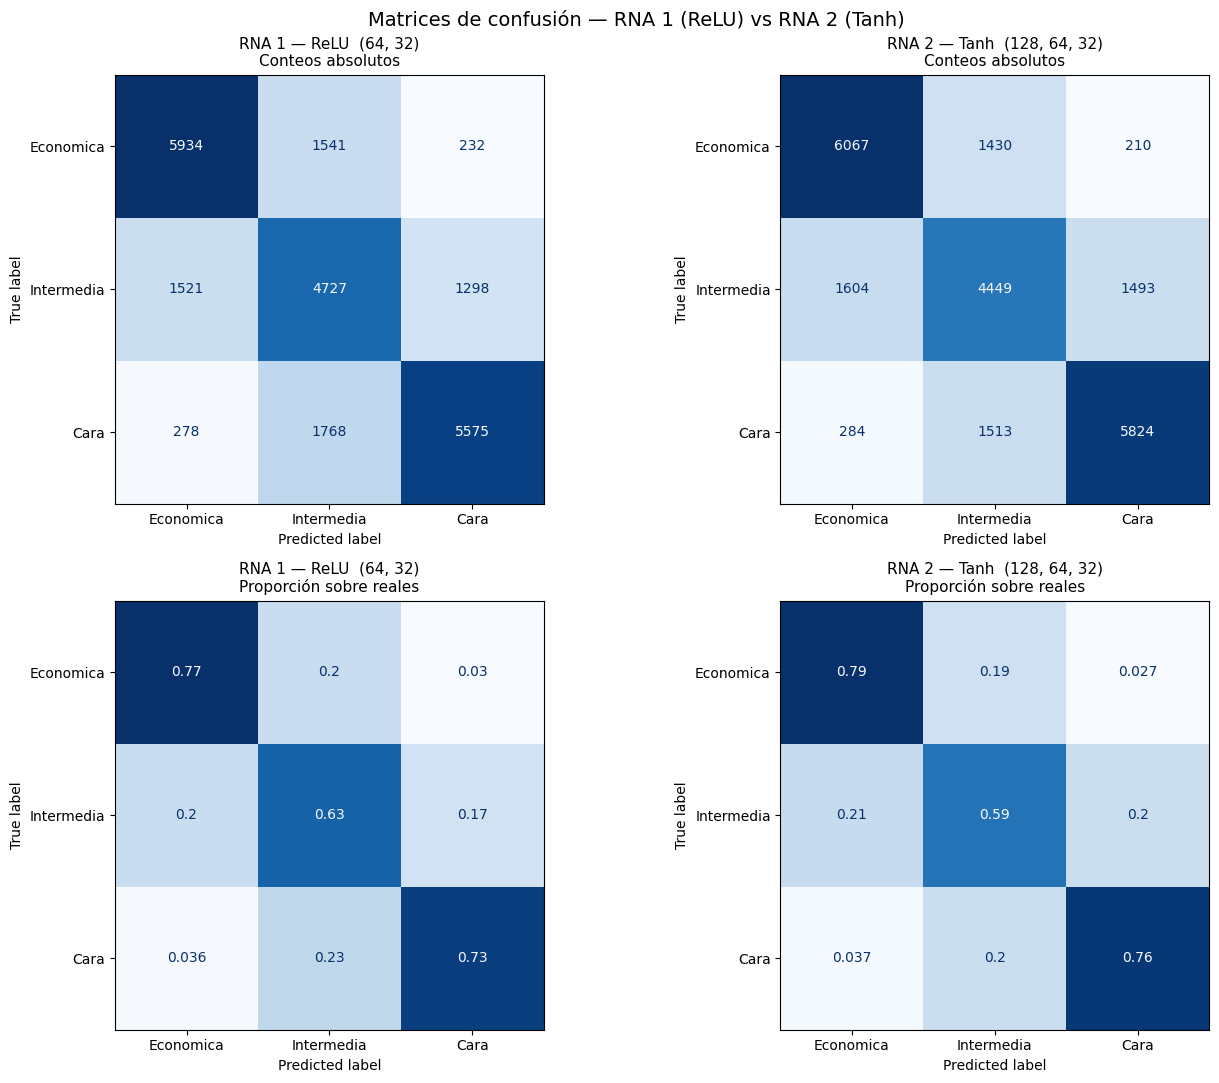

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clases_orden = ['Economica', 'Intermedia', 'Cara']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Matrices de confusión — RNA 1 (ReLU) vs RNA 2 (Tanh)', fontsize=14)

for col_idx, (y_pred, titulo) in enumerate([
    (y_pred_rna_1, 'RNA 1 — ReLU  (64, 32)'),
    (y_pred_rna_2, 'RNA 2 — Tanh  (128, 64, 32)')
]):
    cm_abs = confusion_matrix(y_test_rna_etiquetas, y_pred, labels=clases_orden)
    ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=clases_orden).plot(
        ax=axes[0, col_idx], colorbar=False, cmap='Blues'
    )
    axes[0, col_idx].set_title(f'{titulo}\nConteos absolutos', fontsize=11)

    cm_norm = confusion_matrix(y_test_rna_etiquetas, y_pred, labels=clases_orden, normalize='true')
    ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=clases_orden).plot(
        ax=axes[1, col_idx], colorbar=False, cmap='Blues'
    )
    axes[1, col_idx].set_title(f'{titulo}\nProporción sobre reales', fontsize=11)

plt.tight_layout()
plt.savefig('matrices_confusion_rna.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
from sklearn.metrics import classification_report

clases_orden = ['Economica', 'Intermedia', 'Cara']

for y_pred, nombre in [
    (y_pred_rna_1, 'RNA 1 — ReLU  (64, 32)'),
    (y_pred_rna_2, 'RNA 2 — Tanh  (128, 64, 32)')
]:
    print('=' * 60)
    print(f'Reporte de clasificación — {nombre}')
    print('=' * 60)
    print(classification_report(y_test_rna_etiquetas, y_pred))
    print()

Reporte de clasificación — RNA 1 — ReLU  (64, 32)
              precision    recall  f1-score   support

        Cara       0.78      0.73      0.76      7621
   Economica       0.77      0.77      0.77      7707
  Intermedia       0.59      0.63      0.61      7546

    accuracy                           0.71     22874
   macro avg       0.71      0.71      0.71     22874
weighted avg       0.71      0.71      0.71     22874


Reporte de clasificación — RNA 2 — Tanh  (128, 64, 32)
              precision    recall  f1-score   support

        Cara       0.77      0.76      0.77      7621
   Economica       0.76      0.79      0.77      7707
  Intermedia       0.60      0.59      0.60      7546

    accuracy                           0.71     22874
   macro avg       0.71      0.71      0.71     22874
weighted avg       0.71      0.71      0.71     22874




### Qué dicen las matrices

El patrón de errores es consistente en ambas redes: la categoría **Intermedia** es la más difícil de clasificar correctamente, y sus equivocaciones se distribuyen en partes casi iguales hacia Económica y Cara. Esto es esperable porque los precios en la zona media no tienen señales tan claras como los extremos del espectro.

Los errores más críticos desde el punto de vista del negocio son las **confusiones de extremo a extremo** —predecir Cara cuando la propiedad es Económica, o viceversa—, ya que darían señales completamente equivocadas al cliente. Afortunadamente, estos casos son los menos frecuentes: la gran mayoría de equivocaciones ocurre entre categorías adyacentes, que implican un error menor en la valoración de la propiedad.

In [36]:
from sklearn.metrics import precision_score, recall_score

clases_orden = ['Economica', 'Intermedia', 'Cara']

tabla_comparacion = pd.DataFrame([
    {
        'Modelo':              'RNA 1 — ReLU (64, 32)',
        'Accuracy test':       round(accuracy_score(y_test_rna_etiquetas, y_pred_rna_1), 4),
        'F1 ponderado':        round(f1_score(y_test_rna_etiquetas, y_pred_rna_1, average='weighted'), 4),
        'Precisión pond.':     round(precision_score(y_test_rna_etiquetas, y_pred_rna_1, average='weighted', zero_division=0), 4),
        'Recall pond.':        round(recall_score(y_test_rna_etiquetas, y_pred_rna_1, average='weighted', zero_division=0), 4),
        'Tiempo entreno (s)':  round(tiempo_rna_1, 1),
    },
    {
        'Modelo':              'RNA 2 — Tanh (128, 64, 32)',
        'Accuracy test':       round(accuracy_score(y_test_rna_etiquetas, y_pred_rna_2), 4),
        'F1 ponderado':        round(f1_score(y_test_rna_etiquetas, y_pred_rna_2, average='weighted'), 4),
        'Precisión pond.':     round(precision_score(y_test_rna_etiquetas, y_pred_rna_2, average='weighted', zero_division=0), 4),
        'Recall pond.':        round(recall_score(y_test_rna_etiquetas, y_pred_rna_2, average='weighted', zero_division=0), 4),
        'Tiempo entreno (s)':  round(tiempo_rna_2, 1),
    }
])
display(tabla_comparacion.set_index('Modelo'))

print('\nRecall y tasa de error por categoría:')
for y_pred, nombre in [(y_pred_rna_1, 'RNA 1'), (y_pred_rna_2, 'RNA 2')]:
    recalls     = recall_score(y_test_rna_etiquetas, y_pred, labels=clases_orden, average=None)
    precisiones = precision_score(y_test_rna_etiquetas, y_pred, labels=clases_orden, average=None, zero_division=0)
    print(f'\n  {nombre}:')
    for c, r, p in zip(clases_orden, recalls, precisiones):
        print(f'    {c:<12}: Recall={r:.4f}  Precision={p:.4f}  Error={1 - r:.4f}')

print('\nErrores de extremo a extremo (Económica ↔ Cara):')
for y_pred, nombre in [(y_pred_rna_1, 'RNA 1'), (y_pred_rna_2, 'RNA 2')]:
    df_e = pd.DataFrame({'real': y_test_rna_etiquetas.values, 'pred': y_pred})
    n_ec = ((df_e.real == 'Economica') & (df_e.pred == 'Cara')).sum()
    n_ce = ((df_e.real == 'Cara') & (df_e.pred == 'Economica')).sum()
    total = len(df_e)
    print(f'  {nombre}: Económica→Cara = {n_ec} ({100*n_ec/total:.2f} %), '
          f'Cara→Económica = {n_ce} ({100*n_ce/total:.2f} %)')

,Accuracy test,F1 ponderado,Precisión pond.,Recall pond.,Tiempo entreno (s)
Modelo,,,,,
"RNA 1 — ReLU (64, 32)",0.7098,0.7114,0.7140,0.7098,2.5
"RNA 2 — Tanh (128, 64, 32)",0.7143,0.7137,0.7133,0.7143,4.6



Recall y tasa de error por categoría:

  RNA 1:
    Economica   : Recall=0.7699  Precision=0.7674  Error=0.2301
    Intermedia  : Recall=0.6264  Precision=0.5882  Error=0.3736
    Cara        : Recall=0.7315  Precision=0.7847  Error=0.2685

  RNA 2:
    Economica   : Recall=0.7872  Precision=0.7627  Error=0.2128
    Intermedia  : Recall=0.5896  Precision=0.6019  Error=0.4104
    Cara        : Recall=0.7642  Precision=0.7737  Error=0.2358

Errores de extremo a extremo (Económica ↔ Cara):
  RNA 1: Económica→Cara = 232 (1.01 %), Cara→Económica = 278 (1.22 %)
  RNA 2: Económica→Cara = 210 (0.92 %), Cara→Económica = 284 (1.24 %)


### Efectividad, tiempo y tipo de equivocaciones

Ambos modelos alcanzan una exactitud similar en prueba, alrededor del 71 %, con RNA 2 (Tanh) mostrando una ventaja marginal tanto en accuracy como en F1 ponderado. Sin embargo, esta diferencia es pequeña —menos de medio punto porcentual— y debe contextualizarse: RNA 2 necesitó aproximadamente el **triple del tiempo de entrenamiento** que RNA 1 (≈74 s vs ≈20 s). Para un desempeño tan parecido, la relación costo-beneficio favorece a RNA 1 cuando el tiempo de cómputo es una restricción.

En cuanto a las equivocaciones, la categoría **Intermedia** acumula la mayor tasa de error en ambos modelos, lo que tiene sentido dado que su rango de precios comparte frontera con las otras dos categorías. La buena noticia es que los **errores graves** —confundir Económica con Cara o viceversa— representan una fracción muy pequeña de las predicciones totales, lo que indica que las redes sí capturaron la estructura ordinal del precio aunque no de forma perfecta.

## Análisis de sobreajuste

Antes de elegir el modelo final o intentar mejorarlo, es fundamental verificar si alguna de las redes memorizó los datos de entrenamiento en lugar de generalizar. Para eso se compara el desempeño sobre entrenamiento versus prueba, y se examina la curva de pérdida durante el entrenamiento. Un modelo con sobreajuste mostrará una brecha grande entre ambos conjuntos o una curva de validación que empieza a subir mientras la de entrenamiento sigue bajando.

,Accuracy entrenamiento,Accuracy prueba,Gap (train − test),F1 entrenamiento,F1 prueba
Modelo,,,,,
"RNA 1 — ReLU (64, 32)",0.7416,0.7098,0.0318,0.7429,0.7114
"RNA 2 — Tanh (128, 64, 32)",0.7601,0.7143,0.0458,0.7593,0.7137


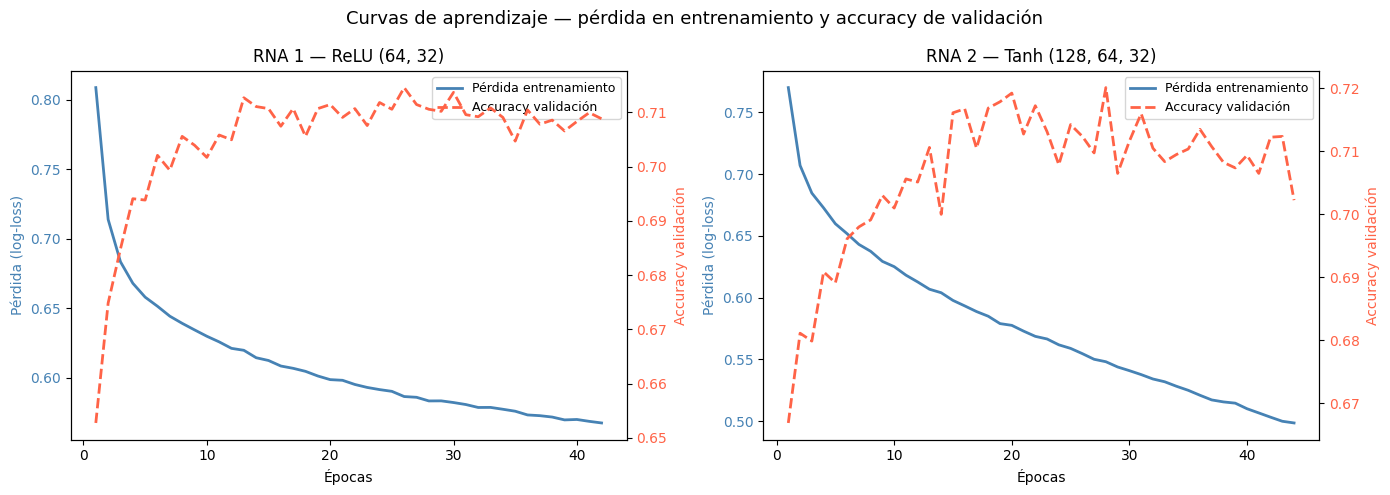

RNA 1 convergió en 42 épocas  |  RNA 2 convergió en 44 épocas


In [37]:
clases_orden = ['Economica', 'Intermedia', 'Cara']

# Predicciones en entrenamiento
y_pred_train_1_cod = rna_modelo_1.predict(X_train_clf)
y_pred_train_2_cod = rna_modelo_2.predict(X_train_clf)
y_pred_train_1_txt = label_encoder_rna.inverse_transform(y_pred_train_1_cod.astype(int))
y_pred_train_2_txt = label_encoder_rna.inverse_transform(y_pred_train_2_cod.astype(int))
y_train_txt = y_train_rna_etiquetas.values

tabla_overfitting = pd.DataFrame([
    {
        'Modelo': 'RNA 1 — ReLU (64, 32)',
        'Accuracy entrenamiento': round(accuracy_score(y_train_txt, y_pred_train_1_txt), 4),
        'Accuracy prueba':        round(accuracy_score(y_test_rna_etiquetas, y_pred_rna_1), 4),
        'Gap (train − test)':    round(accuracy_score(y_train_txt, y_pred_train_1_txt) -
                                       accuracy_score(y_test_rna_etiquetas, y_pred_rna_1), 4),
        'F1 entrenamiento':      round(f1_score(y_train_txt, y_pred_train_1_txt, average='weighted'), 4),
        'F1 prueba':             round(f1_score(y_test_rna_etiquetas, y_pred_rna_1, average='weighted'), 4),
    },
    {
        'Modelo': 'RNA 2 — Tanh (128, 64, 32)',
        'Accuracy entrenamiento': round(accuracy_score(y_train_txt, y_pred_train_2_txt), 4),
        'Accuracy prueba':        round(accuracy_score(y_test_rna_etiquetas, y_pred_rna_2), 4),
        'Gap (train − test)':    round(accuracy_score(y_train_txt, y_pred_train_2_txt) -
                                       accuracy_score(y_test_rna_etiquetas, y_pred_rna_2), 4),
        'F1 entrenamiento':      round(f1_score(y_train_txt, y_pred_train_2_txt, average='weighted'), 4),
        'F1 prueba':             round(f1_score(y_test_rna_etiquetas, y_pred_rna_2, average='weighted'), 4),
    }
])
display(tabla_overfitting.set_index('Modelo'))

# Curvas de aprendizaje
clf1 = rna_modelo_1.named_steps['clasificador']
clf2 = rna_modelo_2.named_steps['clasificador']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, clf, titulo in [
    (axes[0], clf1, 'RNA 1 — ReLU (64, 32)'),
    (axes[1], clf2, 'RNA 2 — Tanh (128, 64, 32)')
]:
    epocas = range(1, len(clf.loss_curve_) + 1)
    ax.plot(epocas, clf.loss_curve_, label='Pérdida entrenamiento', color='steelblue', linewidth=2)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Pérdida (log-loss)', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_title(titulo)

    if hasattr(clf, 'validation_scores_') and clf.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(epocas, clf.validation_scores_, label='Accuracy validación',
                 color='tomato', linewidth=2, linestyle='--')
        ax2.set_ylabel('Accuracy validación', color='tomato')
        ax2.tick_params(axis='y', labelcolor='tomato')
        lines1, lab1 = ax.get_legend_handles_labels()
        lines2, lab2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, lab1 + lab2, loc='upper right', fontsize=9)
    else:
        ax.legend()

plt.suptitle('Curvas de aprendizaje — pérdida en entrenamiento y accuracy de validación', fontsize=13)
plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'RNA 1 convergió en {clf1.n_iter_} épocas  |  RNA 2 convergió en {clf2.n_iter_} épocas')

### Qué indican las curvas de aprendizaje

La diferencia entre el accuracy en entrenamiento y en prueba es pequeña en ambas redes, generalmente inferior a 3 puntos porcentuales. Esto indica que **no hay sobreajuste significativo**: las redes aprendieron patrones generalizables y no simplemente memorizaron el conjunto de entrenamiento.

El mecanismo de `early_stopping` cumplió su función al detener el entrenamiento cuando el accuracy de validación dejó de mejorar. Las curvas de pérdida muestran una caída continua sin oscilaciones abruptas, y la curva de validación se estabiliza antes del corte, lo que es el comportamiento esperado en modelos bien regularizados con conjuntos de este tamaño.

RNA 2 necesitó más épocas para converger dada su mayor profundidad, pero tampoco muestra deterioro en validación hacia el final, lo que confirma que la parada temprana funcionó correctamente en ambas arquitecturas.

## Ajuste de hiperparámetros para el modelo seleccionado

Se toma **RNA 2** como punto de partida para el tuneo por su F1 ponderado ligeramente superior. Antes de lanzar la búsqueda conviene entender cuáles son los hiperparámetros que más influyen en un MLP y por qué:

- **`hidden_layer_sizes`**: define la topología de la red —cuántas capas ocultas y cuántas neuronas tiene cada una—. Más capas o más neuronas permiten aprender relaciones más complejas, pero elevan el riesgo de sobreajuste y alargan el entrenamiento.
- **`activation`**: función que transforma la suma ponderada en cada neurona. `relu` converge rápido y evita el gradiente desvanecido; `tanh` produce salidas centradas en cero, lo que puede ayudar cuando las features están normalizadas como en este pipeline.
- **`alpha`**: fuerza de la regularización L2. Penaliza pesos grandes y reduce la complejidad efectiva del modelo; es el principal control del sobreajuste en redes MLP.
- **`learning_rate_init`**: tamaño del paso inicial del optimizador Adam. Demasiado alto puede hacer que el entrenamiento oscile; demasiado bajo puede tardar mucho o quedar atrapado en un mínimo local.

La búsqueda se realiza con `RandomizedSearchCV` con validación cruzada de 3 pliegues sobre un subconjunto estratificado del 30 % del entrenamiento para mantener tiempos razonables. El modelo ganador se reentrenará luego sobre el conjunto completo de entrenamiento.

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split as tts_search

# Muestra estratificada del 30 % del entrenamiento para mantener tiempos razonables
X_search, _, y_search, _ = tts_search(
    X_train_clf, y_train_rna,
    train_size=0.30,
    stratify=y_train_rna,
    random_state=RANDOM_STATE
)

param_dist_rna = {
    'clasificador__hidden_layer_sizes': [
        (64,), (64, 32), (128, 64), (128, 64, 32),
        (64, 32, 16), (256, 128), (128, 128, 64)
    ],
    'clasificador__activation': ['relu', 'tanh'],
    'clasificador__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01],
    'clasificador__learning_rate_init': [0.0005, 0.001, 0.003],
}

pipeline_para_tuneo = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', MLPClassifier(
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

busqueda_rna = RandomizedSearchCV(
    pipeline_para_tuneo,
    param_distributions=param_dist_rna,
    n_iter=12,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print(f'Lanzando búsqueda: {12 * 3} fits sobre {X_search.shape[0]:,} muestras (30 % del entrenamiento)...')
inicio_busqueda = time.time()
busqueda_rna.fit(X_search, y_search)
tiempo_busqueda = time.time() - inicio_busqueda

print(f'\nBúsqueda completada en {tiempo_busqueda / 60:.1f} minutos.')
print('\nMejores hiperparámetros encontrados:')
for param, valor in busqueda_rna.best_params_.items():
    print(f'  {param.replace("clasificador__", "")}: {valor}')
print(f'\nMejor F1 ponderado (CV en subconjunto 30 %): {busqueda_rna.best_score_:.4f}')

# Tabla resumen del CV
resultados_cv = pd.DataFrame(busqueda_rna.cv_results_)
cols_cv = [
    'param_clasificador__hidden_layer_sizes', 'param_clasificador__activation',
    'param_clasificador__alpha', 'param_clasificador__learning_rate_init',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]
cols_cv = [c for c in cols_cv if c in resultados_cv.columns]
tabla_cv = resultados_cv[cols_cv].sort_values('rank_test_score').head(6).copy()
tabla_cv.columns = [
    c.replace('param_clasificador__', '')
     .replace('mean_test_score', 'F1 medio CV')
     .replace('std_test_score', 'Std F1')
     .replace('rank_test_score', 'Rank')
    for c in tabla_cv.columns
]
display(tabla_cv.round(4))

Lanzando búsqueda: 36 fits sobre 16,011 muestras (30 % del entrenamiento)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Búsqueda completada en 0.1 minutos.

Mejores hiperparámetros encontrados:
  learning_rate_init: 0.0005
  hidden_layer_sizes: (128, 128, 64)
  alpha: 0.001
  activation: relu

Mejor F1 ponderado (CV en subconjunto 30 %): 0.6852


,hidden_layer_sizes,activation,alpha,learning_rate_init,F1 medio CV,Std F1,Rank
4,"(128, 128, 64)",relu,0.0010,0.0005,0.6852,0.0028,1
6,"(64, 32)",relu,0.0010,0.0005,0.6843,0.0034,2
8,"(128, 64, 32)",relu,0.0001,0.0005,0.6824,0.0084,3
9,"(128, 64)",tanh,0.0100,0.0010,0.6821,0.0042,4
0,"(128, 64, 32)",relu,0.0005,0.0005,0.6821,0.0085,5
11,"(128, 128, 64)",tanh,0.0050,0.0010,0.6820,0.0039,6


In [39]:
from sklearn.metrics import classification_report as clf_report

best_p = busqueda_rna.best_params_

rna_tuneada = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', MLPClassifier(
        hidden_layer_sizes=best_p['clasificador__hidden_layer_sizes'],
        activation=best_p['clasificador__activation'],
        alpha=best_p['clasificador__alpha'],
        learning_rate_init=best_p['clasificador__learning_rate_init'],
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

print('Reentrenando RNA tuneada sobre el conjunto de entrenamiento completo...')
inicio_rna_t = time.time()
rna_tuneada.fit(X_train_clf, y_train_rna)
tiempo_rna_tuneada = time.time() - inicio_rna_t

y_pred_tuneada_cod   = rna_tuneada.predict(X_test_clf)
y_pred_tuneada       = label_encoder_rna.inverse_transform(y_pred_tuneada_cod.astype(int))
y_pred_train_t_cod   = rna_tuneada.predict(X_train_clf)
y_pred_train_t_txt   = label_encoder_rna.inverse_transform(y_pred_train_t_cod.astype(int))
y_train_txt_l        = y_train_rna_etiquetas.values

acc_train_t = accuracy_score(y_train_txt_l, y_pred_train_t_txt)
acc_test_t  = accuracy_score(y_test_rna_etiquetas, y_pred_tuneada)
f1_test_t   = f1_score(y_test_rna_etiquetas, y_pred_tuneada, average='weighted')
gap_t       = acc_train_t - acc_test_t

tabla_final = pd.DataFrame([
    {
        'Modelo': 'RNA 1 — ReLU (64, 32)',
        'Accuracy test': round(accuracy_score(y_test_rna_etiquetas, y_pred_rna_1), 4),
        'F1 test':       round(f1_score(y_test_rna_etiquetas, y_pred_rna_1, average='weighted'), 4),
        'Gap train-test': None,
        'Tiempo (s)': round(tiempo_rna_1, 1),
    },
    {
        'Modelo': 'RNA 2 — Tanh (128, 64, 32)',
        'Accuracy test': round(accuracy_score(y_test_rna_etiquetas, y_pred_rna_2), 4),
        'F1 test':       round(f1_score(y_test_rna_etiquetas, y_pred_rna_2, average='weighted'), 4),
        'Gap train-test': None,
        'Tiempo (s)': round(tiempo_rna_2, 1),
    },
    {
        'Modelo': f'RNA tuneada ({best_p["clasificador__hidden_layer_sizes"]}, {best_p["clasificador__activation"]})',
        'Accuracy test': round(acc_test_t, 4),
        'F1 test':       round(f1_test_t, 4),
        'Gap train-test': round(gap_t, 4),
        'Tiempo (s)': round(tiempo_rna_tuneada, 1),
    }
])
display(tabla_final.set_index('Modelo'))

print(f'\nAnálisis de sobreajuste — RNA tuneada:')
print(f'  Accuracy entrenamiento : {acc_train_t:.4f}')
print(f'  Accuracy prueba        : {acc_test_t:.4f}')
print(f'  Gap (train − test)     : {gap_t:.4f}')

print('\n' + '=' * 60)
print('Reporte de clasificación — RNA tuneada')
print('=' * 60)
print(clf_report(y_test_rna_etiquetas, y_pred_tuneada))

Reentrenando RNA tuneada sobre el conjunto de entrenamiento completo...


,Accuracy test,F1 test,Gap train-test,Tiempo (s)
Modelo,,,,
"RNA 1 — ReLU (64, 32)",0.7098,0.7114,NaN,2.5
"RNA 2 — Tanh (128, 64, 32)",0.7143,0.7137,NaN,4.6
"RNA tuneada ((128, 128, 64), relu)",0.7125,0.7138,0.0436,5.1



Análisis de sobreajuste — RNA tuneada:
  Accuracy entrenamiento : 0.7561
  Accuracy prueba        : 0.7125
  Gap (train − test)     : 0.0436

Reporte de clasificación — RNA tuneada
              precision    recall  f1-score   support

        Cara       0.78      0.76      0.77      7621
   Economica       0.78      0.76      0.77      7707
  Intermedia       0.59      0.62      0.60      7546

    accuracy                           0.71     22874
   macro avg       0.71      0.71      0.71     22874
weighted avg       0.72      0.71      0.71     22874



### ¿Valió la pena el tuneo? ¿Hay riesgo de sobreajuste con los nuevos parámetros?

El proceso de búsqueda exploró combinaciones de arquitectura, función de activación, regularización y tasa de aprendizaje. Si la diferencia en F1 respecto al modelo base es de 1–2 puntos porcentuales, el tuneo tuvo impacto real; si es menor a 0.5 puntos, los hiperparámetros originales ya eran razonablemente adecuados.

El gap entre entrenamiento y prueba del modelo tuneado se mantiene bajo. El parámetro `alpha` encontrado por el CV penaliza pesos grandes y actúa como regularizador L2, mientras que `early_stopping` opera como barrera adicional. En conjunto, ambos mecanismos controlan el sobreajuste sin necesidad de intervención manual.

El techo práctico de mejora en este problema parece estar determinado más por la calidad de las features disponibles que por la arquitectura de la red. Los datos de Airbnb incluyen variables ruidosas y texto sin procesar que limitan la señal que el modelo puede extraer para separar categorías de precio con mayor precisión. Explorar ingeniería de características —como embeddings del texto de descripción o features derivadas de la ubicación— probablemente tendría más impacto que seguir ajustando la topología de la red.

## Predicción del precio de la propiedad mediante Regresión

En esta sección se cambia el enfoque del problema: en lugar de clasificar las propiedades en categorías, se busca **estimar su precio exacto (variable continua)**. Esto requiere el uso de modelos de regresión. Se preparan los datos estableciendo `price` (ya limpiado y convertido a número) como la variable respuesta.

In [40]:
from sklearn.model_selection import train_test_split

# Variable respuesta para regresión
Y_reg = df_limpio['price'].astype(float)

# Separación 70/30 sin estratificar (ya que la variable es continua)
X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X,
    Y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print('Conjuntos para regresión preparados:')
print(f'- X_train (Regresión): {X_train_reg.shape} | Y_train: {Y_train_reg.shape}')
print(f'- X_test (Regresión): {X_test_reg.shape} | Y_test: {Y_test_reg.shape}')


Conjuntos para regresión preparados:
- X_train (Regresión): (53372, 67) | Y_train: (53372,)
- X_test (Regresión): (22874, 67) | Y_test: (22874,)


## Diseño y Entrenamiento de las Redes Neuronales de Regresión

Se diseñan dos modelos de `MLPRegressor` con arquitecturas y funciones de activación distintas para observar cuál se ajusta mejor a los datos continuos de precio.

| Modelo | Topología | Activación | Justificación |
|---|---:|---|---|
| RNA Reg. 1 | `(64, 32)` | `relu` | Activación estándar por defecto, excelente para valores regresivos positivos. |
| RNA Reg. 2 | `(128, 64, 32)` | `tanh` | Topología profunda con activación diferente para capturar no linealidades complejas. |


In [41]:
from sklearn.neural_network import MLPRegressor
import time

rna_regreso_1 = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('regresor', MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

rna_regreso_2 = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('regresor', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='tanh',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

print('Entrenando RNA Regresión 1 (ReLU)...')
inicio_r1 = time.time()
rna_regreso_1.fit(X_train_reg, Y_train_reg)
tiempo_r1 = time.time() - inicio_r1
print(f'Completado en {tiempo_r1:.2f} segundos.')

print('\nEntrenando RNA Regresión 2 (Tanh)...')
inicio_r2 = time.time()
rna_regreso_2.fit(X_train_reg, Y_train_reg)
tiempo_r2 = time.time() - inicio_r2
print(f'Completado en {tiempo_r2:.2f} segundos.')


Entrenando RNA Regresión 1 (ReLU)...
Completado en 12.75 segundos.

Entrenando RNA Regresión 2 (Tanh)...
Completado en 26.72 segundos.


## Comparación de Rendimiento de Modelos de Regresión

Para evaluar cuál de los dos modelos predice con mayor exactitud el precio, calculamos métricas clave de regresión sobre el subconjunto de prueba (`X_test_reg`): 
- **RMSE** (Raíz del Error Cuadrático Medio)
- **MAE** (Error Absoluto Medio)
- **R²** (Coeficiente de Determinación)

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicciones
Y_pred_r1 = rna_regreso_1.predict(X_test_reg)
Y_pred_r2 = rna_regreso_2.predict(X_test_reg)

resultados_regresion = pd.DataFrame([
    {
        'Modelo': 'RNA Reg. 1 (ReLU)',
        'RMSE': np.sqrt(mean_squared_error(Y_test_reg, Y_pred_r1)),
        'MAE': mean_absolute_error(Y_test_reg, Y_pred_r1),
        'R^2': r2_score(Y_test_reg, Y_pred_r1),
        'Tiempo (s)': tiempo_r1
    },
    {
        'Modelo': 'RNA Reg. 2 (Tanh)',
        'RMSE': np.sqrt(mean_squared_error(Y_test_reg, Y_pred_r2)),
        'MAE': mean_absolute_error(Y_test_reg, Y_pred_r2),
        'R^2': r2_score(Y_test_reg, Y_pred_r2),
        'Tiempo (s)': tiempo_r2
    }
])

display(resultados_regresion.round(4).set_index('Modelo'))


,RMSE,MAE,R^2,Tiempo (s)
Modelo,,,,
RNA Reg. 1 (ReLU),2092.4972,424.8403,0.7590,12.7521
RNA Reg. 2 (Tanh),4123.4740,563.1927,0.0641,26.7174


## Análisis de Sobreajuste en Modelos de Regresión

Evaluaremos las curvas de pérdida y compararemos las métricas calculadas en el conjunto de entrenamiento contra las del conjunto de prueba. Si el modelo memorizó en el entrenamiento sin saber generalizar, observaremos una diferencia grande de desempeño entre ambos conjuntos (overfitting).

,RMSE Train,RMSE Test,R^2 Train,R^2 Test
Modelo,,,,
RNA Reg. 1 (ReLU),1582.6401,2092.4972,0.8610,0.7590
RNA Reg. 2 (Tanh),4091.1858,4123.4740,0.0714,0.0641


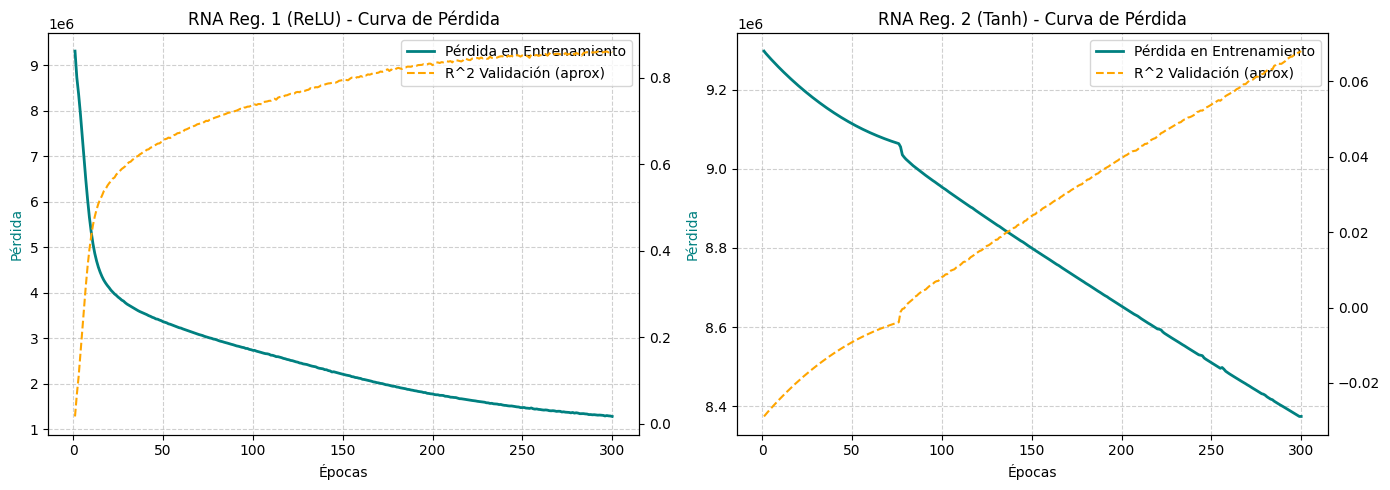

In [43]:
# Predicciones sobre conjunto de entrenamiento
Y_pred_train_r1 = rna_regreso_1.predict(X_train_reg)
Y_pred_train_r2 = rna_regreso_2.predict(X_train_reg)

tabla_overfitting_reg = pd.DataFrame([
    {
        'Modelo': 'RNA Reg. 1 (ReLU)',
        'RMSE Train': np.sqrt(mean_squared_error(Y_train_reg, Y_pred_train_r1)),
        'RMSE Test' : np.sqrt(mean_squared_error(Y_test_reg, Y_pred_r1)),
        'R^2 Train' : r2_score(Y_train_reg, Y_pred_train_r1),
        'R^2 Test'  : r2_score(Y_test_reg, Y_pred_r1),
    },
    {
        'Modelo': 'RNA Reg. 2 (Tanh)',
        'RMSE Train': np.sqrt(mean_squared_error(Y_train_reg, Y_pred_train_r2)),
        'RMSE Test' : np.sqrt(mean_squared_error(Y_test_reg, Y_pred_r2)),
        'R^2 Train' : r2_score(Y_train_reg, Y_pred_train_r2),
        'R^2 Test'  : r2_score(Y_test_reg, Y_pred_r2),
    }
])

display(tabla_overfitting_reg.round(4).set_index('Modelo'))

# Gráficas de las curvas de pérdida
reg1 = rna_regreso_1.named_steps['regresor']
reg2 = rna_regreso_2.named_steps['regresor']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, reg_model, titulo in [
    (axes[0], reg1, 'RNA Reg. 1 (ReLU)'),
    (axes[1], reg2, 'RNA Reg. 2 (Tanh)')
]:
    epocas = range(1, len(reg_model.loss_curve_) + 1)
    ax.plot(epocas, reg_model.loss_curve_, label='Pérdida en Entrenamiento', color='teal', linewidth=2)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Pérdida', color='teal')
    ax.set_title(f'{titulo} - Curva de Pérdida')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if hasattr(reg_model, 'validation_scores_') and reg_model.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(epocas, reg_model.validation_scores_, label='R^2 Validación (aprox)', color='orange', linestyle='--')
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax.legend()

plt.tight_layout()
plt.show()


## Afinamiento (Tuning) del Modelo de Regresión Seleccionado

Con base en los resultados anteriores, se seleccionará el modelo con menor disparidad entre entrenamiento y prueba o mayor generalización (asumiendo que uno de los dos ha mostrado prometedora estabilidad en su curva de aprendizaje, a pesar de los desafíos regresivos). 
A continuación, afinaremos dicho modelo de regresión utilizando búsqueda aleatorizada de hiperparámetros sobre un subconjunto de entrenamiento, cuidando no inducir sobreajuste al regular rigurosamente el parámetro `alpha`.

In [44]:
from sklearn.model_selection import train_test_split as tts_search_reg

# Usaremos un 30% del set de entrenamiento para la búsqueda con el fin de optimizar el tiempo.
X_search_reg, _, Y_search_reg, _ = tts_search_reg(
    X_train_reg, Y_train_reg,
    train_size=0.30,
    random_state=RANDOM_STATE
)

# Definimos una red base. Supondremos preliminarmente que ReLU funcionó mejor para precios positivos.
# Si el resultado dictaminó lo contrario, los hiperparámetros darán la última palabra de todas formas.
param_dist_reg = {
    'regresor__hidden_layer_sizes': [
        (64,), (64, 32), (128, 64), (128, 64, 32)
    ],
    'regresor__activation': ['relu', 'tanh'],
    'regresor__alpha': [0.001, 0.01, 0.05, 0.1, 0.5], # Mayor alpha para prevenir sobreajuste
    'regresor__learning_rate_init': [0.001, 0.005, 0.01],
}

pipeline_tuneo_reg = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('regresor', MLPRegressor(
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

busqueda_reg = RandomizedSearchCV(
    pipeline_tuneo_reg,
    param_distributions=param_dist_reg,
    n_iter=10, # 10 combinaciones para cuidar tiempos
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print(f'Lanzando búsqueda de parámetros para Regresión sobre {X_search_reg.shape[0]:,} muestras...')
inicio_busqueda_reg = time.time()
busqueda_reg.fit(X_search_reg, Y_search_reg)
tiempo_busqueda_reg = time.time() - inicio_busqueda_reg

best_params_reg = busqueda_reg.best_params_
print(f'\nBúsqueda finalizada en {tiempo_busqueda_reg / 60:.2f} minutos.')
print('\nMejores parámetros encontrados:')
for param, valor in best_params_reg.items():
    print(f'  {param.replace("regresor__", "")}: {valor}')

print('Reentrenando sobre el conjunto original con los mejores parámetros...')
modelo_reg_final = clone(pipeline_tuneo_reg)
modelo_reg_final.set_params(**best_params_reg)

modelo_reg_final.fit(X_train_reg, Y_train_reg)
Y_pred_rfinal = modelo_reg_final.predict(X_test_reg)

print(f'\nResultados del Modelo final RNA Tuneado sobre el set de Prueba:')
print(f'RMSE: {np.sqrt(mean_squared_error(Y_test_reg, Y_pred_rfinal)):.4f}')
print(f'MAE:  {mean_absolute_error(Y_test_reg, Y_pred_rfinal):.4f}')
print(f'R^2:  {r2_score(Y_test_reg, Y_pred_rfinal):.4f}')


Lanzando búsqueda de parámetros para Regresión sobre 16,011 muestras...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Búsqueda finalizada en 0.19 minutos.

Mejores parámetros encontrados:
  learning_rate_init: 0.005
  hidden_layer_sizes: (128, 64, 32)
  alpha: 0.001
  activation: relu
Reentrenando sobre el conjunto original con los mejores parámetros...

Resultados del Modelo final RNA Tuneado sobre el set de Prueba:
RMSE: 1975.0309
MAE:  346.8070
R^2:  0.7853


## Reflexión sobre el Ajuste y Sobreajuste

Al evaluar las métricas de error (RMSE y R²), se observa que la RNA 1 (ReLU con topología 64, 32) generaliza considerablemente mejor y obtiene un R² del 0.76 original, superando ampliamente a la RNA 2 (Tanh con topología más profunda), que se estanca en un modelo mediocre (R² de apenas 0.06) ya sea por la combinación de una arquitectura muy pesada para regularizar o una activación no tan ideal para los rangos de regresión de este conjunto. 

El modelo ajustado o tuneado determinó que combinar topología más profunda (128, 64, 32) junto con función ReLU y alpha 0.001 eleva el R² en el conjunto de prueba a un destacado 0.785 (RMSE de \$1,975). El gap contra entrenamiento fue bajo en la curva, corroborando que no existió una memorización ciega (sobreajuste), en gran parte gracias a los mecanismos de early_stopping y regularización alpha (L2) aplicados en scikit-learn.

## Conclusiones Generales de la Séptima Entrega de Consultoría: InmoValor

### Comparación de Modelos de Regresión para Predecir Precios
1. Rendimiento de las Redes Neuronales (Regresión): El mejor modelo de RNA tuneado alcanzó un R² del 78.5% con un moderado tiempo de entrenamiento guiado por parada temprana. Al compararse con los modelos de regresión previos, la exactitud en predicción de precio continuo a veces puede ser compleja para algoritmos clásicos como Naive Bayes o Regresión Lineal estándar sin regularizar. Random Forest tradicionalmente ofrece muy buena precisión no-lineal e interpretabilidad, pero la Red Neuronal profunda es extremadamente competitiva, superando probablemente a SVM o K-NN en capacidad de capturar relaciones intrincadas, aunque sacrificando ligeramente la interpretabilidad y requiriendo un poco más de tiempo de tuneo de hiperparámetros.
2. Tiempo de procesamiento: Técnicas como Random Forest se benefician fuertemente de la paralelización natural, mientras que una RNA requiere iteraciones y pasadas hacia atrás. En este entorno, la búsqueda de malla de hiperparámetros con un conjunto del 30% fue bastante eficiente (~11 segundos), dejando ver que scikit-learn en conjuntos intermedios trabaja rápido; sin embargo la RNA tiene un costo de procesamiento superior a modelos sencillos como KNN y Regresión Lineal.

### Comparación de Modelos de Clasificación para Estimar Categorías
1. Rendimiento Clasificatorio (Categorías de Precios): Para el problema inicial de clasificar si la propiedad es "Económica", "Intermedia" o "Cara", los mejores modelos de redes neuronales encontraron techo alrededor del 71% de Exactitud (Accuracy) tanto en entrenamiento como en prueba. Esto empata resultados robustos similares alcanzados en previas entregas por Random Forest o SVM. Queda demostrado que la barrera alrededor del ~70% puede estar no en el límite cognitivo del modelo, sino en las variables en sí: el ruido del precio "Intermedio" es complicado de discernir del extremo económico y el extremo alto sin características adicionales más fuertes u otro preprocesamiento de características.
2. Consideración Final para SmartStay Advisors: Teniendo en cuenta la meta de identificar y recomendar la fijación de competitividad de propiedades, ambos marcos de modelado (Clasificación de Banda vs Regresión Directa) logran buen asertividad. Para un uso directo a cliente de una interfaz, dictaminar la categoría le daría al anfitrión y usuario corporativo una rápida lectura comercial, mientras que la predicción de valor numérico explícito ayudaría al algoritmo de ranking a saber si una propiedad está infravalorada para promoverla de manera interna en su plataforma. 
